<a href="https://colab.research.google.com/github/Fahadkhan2450/Emotion-Detection-From-Social-Media-Posts/blob/main/Transformer_Approach_(distilbert_).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import torch
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import DataLoader
from datasets import Dataset
from imblearn.over_sampling import RandomOverSampler
from transformers import (
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding
)
import re
import nltk
from nltk.corpus import stopwords

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("suchintikasarkar/sentiment-analysis-for-mental-health")

print("Path to dataset files:", path)

100%|██████████| 11.1M/11.1M [00:00<00:00, 87.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/suchintikasarkar/sentiment-analysis-for-mental-health/versions/1


In [4]:
import pandas as pd
import os

data = pd.read_csv(os.path.join(path, "Combined Data.csv"))

data.head()

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [5]:
data.dropna(inplace=True)
data.drop(columns=["Unnamed: 0"], inplace=True)
data.reset_index(drop=True, inplace=True)

In [6]:
nltk.download("stopwords", download_dir="/usr/local/nltk_data")
nltk.data.path.append("/usr/local/nltk_data")


stop_words = set(stopwords.words("english"))

stop_words = set(stopwords.words("english"))

def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    words = [word for word in text.split() if word not in stop_words]
    return " ".join(words)

data["statement"] = data["statement"].apply(clean_text)

[nltk_data] Downloading package stopwords to /usr/local/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [7]:
data

,statement,status
0,oh gosh,Anxiety
1,trouble sleeping confused mind restless heart ...,Anxiety
2,wrong back dear forward doubt stay restless re...,Anxiety
3,ive shifted focus something else im still worried,Anxiety
4,im restless restless month boy mean,Anxiety
...,...,...
52676,nobody takes seriously ive dealt depressionanx...,Anxiety
52677,selfishness dont feel good like dont belong wo...,Anxiety
52678,way sleep better cant sleep nights meds didnt ...,Anxiety
52679,public speaking tips hi give presentation work...,Anxiety


In [8]:
data['status'].value_counts()

,count
status,
Normal,16343
Depression,15404
Suicidal,10652
Anxiety,3841
Bipolar,2777
Stress,2587
Personality disorder,1077


In [9]:
ros = RandomOverSampler(sampling_strategy='auto', random_state=42)

X_resampled, y_resampled = ros.fit_resample(
    data[['statement']],
    data['status']
)

data = pd.concat([X_resampled, y_resampled], axis=1)

In [10]:
print(data['status'].value_counts())

status
Anxiety                 16343
Normal                  16343
Depression              16343
Suicidal                16343
Stress                  16343
Bipolar                 16343
Personality disorder    16343
Name: count, dtype: int64


In [11]:
label_encoder=LabelEncoder()
data['label']=label_encoder.fit_transform(data['status'])

In [12]:
train_text,test_text,train_labels,test_labels=train_test_split(data['statement'],data['label'],test_size=0.2,random_state=42)

In [15]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

train_encodings = tokenizer(
    list(train_text),
    truncation=True,
    max_length=256,
    padding=False
)

test_encodings = tokenizer(
    list(test_text),
    truncation=True,
    max_length=256,
    padding=False
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

**converting into Hugging face Dataset**

In [16]:
from datasets import Dataset

train_dataset = Dataset.from_dict({
    "input_ids": train_encodings["input_ids"],
    "attention_mask": train_encodings["attention_mask"],
    "labels": train_labels.tolist()
})

test_dataset = Dataset.from_dict({
    "input_ids": test_encodings["input_ids"],
    "attention_mask": test_encodings["attention_mask"],
    "labels":test_labels.tolist()
})

In [17]:
train_dataset[0]

{'input_ids': [101,
  2253,
  3058,
  10047,
  2391,
  2279,
  5717,
  3325,
  5306,
  2308,
  2236,
  2318,
  22331,
  2611,
  5745,
  2098,
  4851,
  2178,
  10439,
  2471,
  3599,
  2095,
  3283,
  4527,
  2052,
  2674,
  2051,
  2787,
  2175,
  23389,
  2295,
  3271,
  2228,
  3492,
  2714,
  6180,
  2828,
  2502,
  2051,
  3793,
  2121,
  2823,
  4030,
  6869,
  4385,
  2787,
  6135,
  7481,
  2777,
  2409,
  10047,
  10990,
  3124,
  10047,
  3492,
  11771,
  9826,
  2056,
  2785,
  2868,
  2204,
  7729,
  3092,
  3173,
  2398,
  3788,
  23389,
  2103,
  4782,
  2126,
  2482,
  3333,
  2371,
  2066,
  2453,
  3246,
  2356,
  2279,
  2051,
  3437,
  2910,
  2102,
  2130,
  2641,
  2071,
  2412,
  2272,
  23713,
  2595,
  2497,
  2425,
  2619,
  10047,
  2667,
  11655,
  2290,
  2505,
  2742,
  2130,
  2514,
  14710,
  4895,
  13966,
  2066,
  2411,
  3262,
  2503,
  4921,
  2063,
  2409,
  11501,
  2063,
  2412,
  2066,
  3432,
  4895,
  16344,
  5657,
  2514,
  2126,
  3497,
  48

In [18]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [40]:

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(label_encoder.classes_)
)

# Dynamic padding
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

training_args = TrainingArguments(
    output_dir="./results",

    # Training
    num_train_epochs=5,
    learning_rate=2e-5,

    # Batch size
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=1,

    # Optimization
    weight_decay=0.01,
    warmup_steps=50,
    lr_scheduler_type="linear",

    # Evaluation
    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    # Logging
    logging_steps=200,

    # Checkpoints
    save_total_limit=1,

    # GPU
    fp16=True,

    # Data loading
    dataloader_num_workers=2,
    dataloader_pin_memory=True,

    # Disable external logging
    report_to="none",

    seed=42
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.294482,0.290726,0.898212,0.900096,0.898212,0.895376
2,0.215723,0.234810,0.919365,0.922267,0.919365,0.917347
3,0.134902,0.235477,0.929461,0.928661,0.929461,0.928953
4,0.085093,0.295418,0.932127,0.931401,0.932127,0.931492
5,0.049284,0.335210,0.932389,0.931642,0.932389,0.931756


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=28600, training_loss=0.20498922017904428, metrics={'train_runtime': 2865.4929, 'train_samples_per_second': 159.693, 'train_steps_per_second': 9.981, 'total_flos': 2.561584480350499e+16, 'train_loss': 0.20498922017904428, 'epoch': 5.0})

In [41]:
predictions,labels,_=trainer.predict(test_dataset)
predicted_labels=np.argmax(predictions,axis=1)

In [42]:
print(classification_report(test_labels,predicted_labels,target_names=label_encoder.classes_))

                      precision    recall  f1-score   support

             Anxiety       0.97      0.99      0.98      3375
             Bipolar       0.97      0.99      0.98      3214
          Depression       0.87      0.64      0.74      3274
              Normal       0.95      0.92      0.94      3325
Personality disorder       0.99      1.00      1.00      3241
              Stress       0.96      0.99      0.98      3209
            Suicidal       0.74      0.89      0.81      3243

            accuracy                           0.92     22881
           macro avg       0.92      0.92      0.92     22881
        weighted avg       0.92      0.92      0.92     22881



In [43]:
cm=confusion_matrix(test_labels,predicted_labels)
cm

array([[3343,    9,    1,   13,    1,    8,    0],
       [   6, 3193,    4,    3,    3,    2,    3],
       [  52,   57, 2111,   67,   20,   27,  940],
       [  31,   17,   36, 3071,    7,   92,   71],
       [   0,    0,    0,    0, 3241,    0,    0],
       [   6,    5,    2,    4,    0, 3187,    5],
       [   5,    4,  278,   61,    0,    5, 2890]])

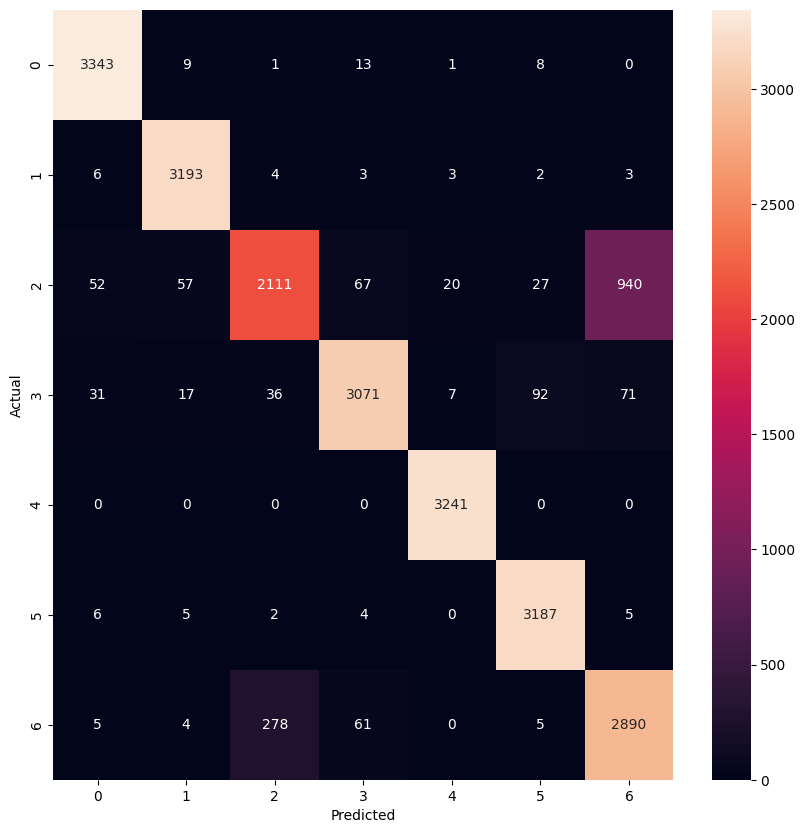

In [44]:
plt.figure(figsize=(10,10))
sns.heatmap(cm,annot=True,fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

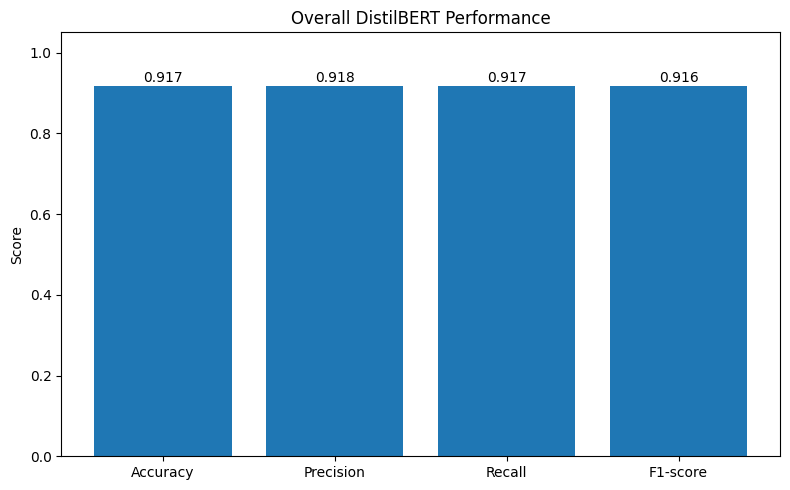

In [46]:
overall_metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1
}

plt.figure(figsize=(8, 5))

bars = plt.bar(
    overall_metrics.keys(),
    overall_metrics.values()
)

plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Overall DistilBERT Performance")

for bar, value in zip(bars, overall_metrics.values()):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.01,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [47]:
history = trainer.state.log_history

history_df = pd.DataFrame(history)

print(history_df.columns)

Index(['loss', 'grad_norm', 'learning_rate', 'epoch', 'step', 'eval_loss',
       'eval_accuracy', 'eval_precision', 'eval_recall', 'eval_f1',
       'eval_runtime', 'eval_samples_per_second', 'eval_steps_per_second',
       'train_runtime', 'train_samples_per_second', 'train_steps_per_second',
       'total_flos', 'train_loss'],
      dtype='object')


In [49]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)

    precision = precision_score(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

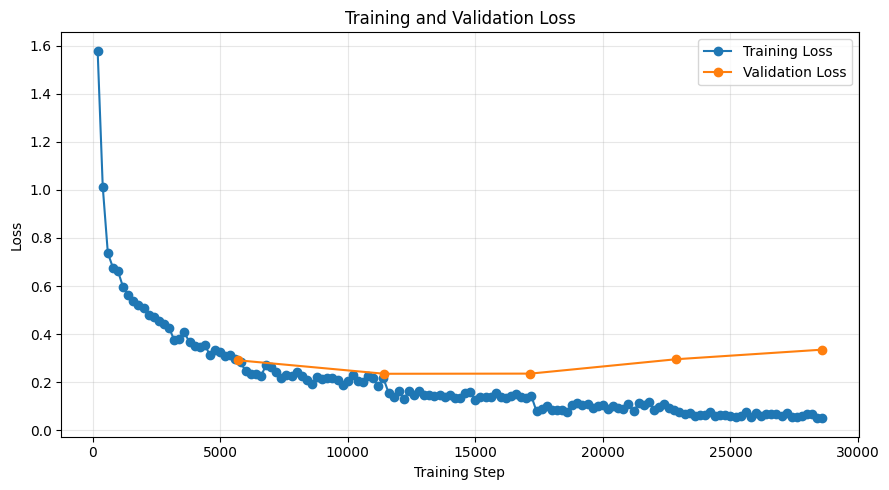

In [51]:
history_df = pd.DataFrame(trainer.state.log_history)

train_loss = history_df[history_df["loss"].notna()]
eval_loss = history_df[history_df["eval_loss"].notna()]

plt.figure(figsize=(9, 5))

plt.plot(
    train_loss["step"],
    train_loss["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    eval_loss["step"],
    eval_loss["eval_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Multiclass ROC , AUC**

In [52]:

y_test_bin = label_binarize(
    true_labels,
    classes=np.arange(len(class_names))
)


roc_auc = roc_auc_score(
    y_test_bin,
    probabilities,
    multi_class="ovr",
    average="weighted"
)

print(f"Weighted ROC-AUC: {roc_auc:.4f}")

Weighted ROC-AUC: 0.9907


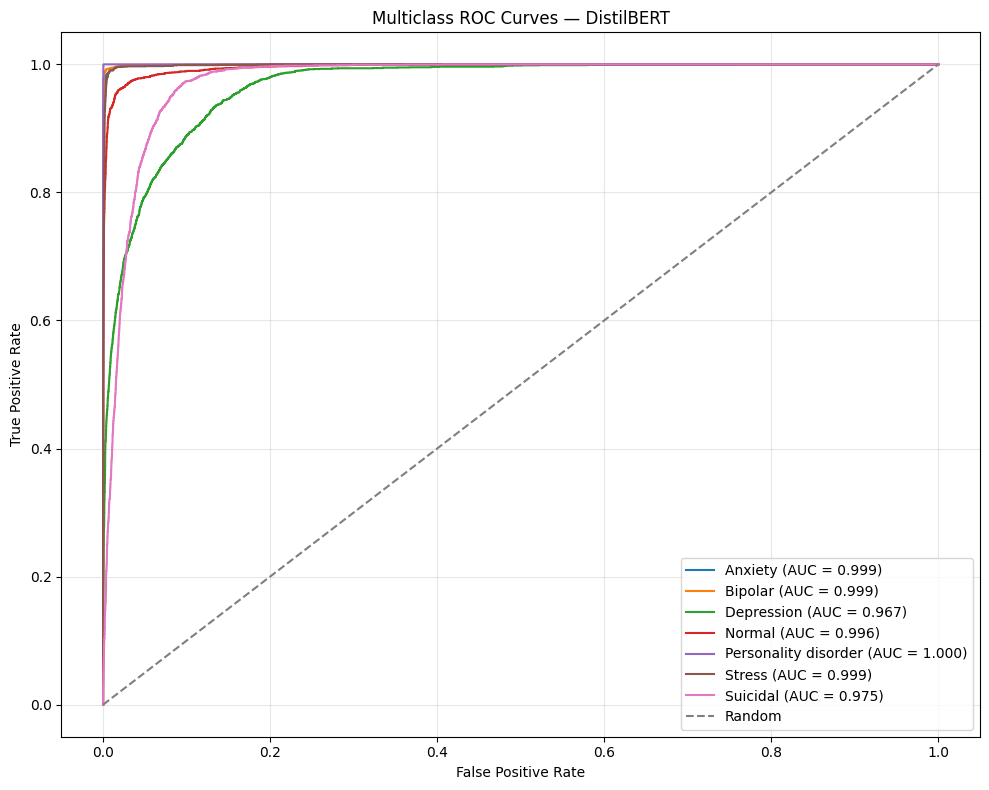

In [53]:
plt.figure(figsize=(10, 5))

for i, class_name in enumerate(class_names):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        probabilities[:, i]
    )

    roc_auc_class = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} (AUC = {roc_auc_class:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curves — DistilBERT")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [54]:
final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1",
        "Weighted ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

final_results["Score"] = final_results["Score"].round(4)

print(final_results)

               Metric   Score
0            Accuracy  0.9174
1  Weighted Precision  0.9176
2     Weighted Recall  0.9174
3         Weighted F1  0.9164
4    Weighted ROC-AUC  0.9907
